In [113]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

Please note that the software in this file is intended to be used as an example for 
how one may run T1 using pulse level access. This software was used during the time
of writing https://doi.org/10.48550/arXiv.2502.06717 and the devices it measured have 
now been decomissioned.

### Run $T_2^*$ Ramsey benchmark on OQC via AWS

Note: IonQ does not support pulse control so $T_2^*$ could not be obtained. Rigetti is currently offline.

In [12]:
import numpy as np

from braket.circuits import Circuit
from braket.aws import AwsDevice
from braket.pulse import PulseSequence

from scipy.optimize import differential_evolution
from datetime import datetime
import matplotlib.pyplot as plt

font_size = 12
plt.rcParams.update({'font.size': font_size})

In [13]:
# Define benchmark parameters
device = AwsDevice("arn:aws:braket:eu-west-2::device/qpu/oqc/Lucy")
frequency_shift = 0
wait_time_s = 2e-7
qubit = 4
qubit_frame = device.frames[f"q{qubit}_drive"]
shots = 1000

frequency_shift_pulse = PulseSequence().shift_frequency(qubit_frame, frequency_shift)
frequency_shift_pulse_neg = PulseSequence().shift_frequency(qubit_frame, -frequency_shift)
wait_pulse = PulseSequence().delay(qubit_frame, wait_time_s)

max_steps = 40
nums_identities = [i for i in range(max_steps)]
print(nums_identities)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [14]:
circuit_list = []
for num_identities in nums_identities:
    t2_circuit = Circuit()

    # Rotate with a Rx(pi/2) gate
    # Phase difference between v and Rx(pi/2) does not matter
    t2_circuit = t2_circuit.v(qubit)

    # Change the frequency of qubit, i.e., detuning
    t2_circuit = t2_circuit.pulse_gate(qubit, frequency_shift_pulse)

    # Add idle gates
    for j in range(num_identities):
        t2_circuit = t2_circuit.pulse_gate(qubit, wait_pulse)

    # Change the frequency back
    t2_circuit = t2_circuit.pulse_gate(qubit, frequency_shift_pulse_neg)

    # Rotate back
    t2_circuit.v(qubit)

    # Verbatim compilation - make sure circuit is not optimised
    t2_circuit_verbatim = Circuit().add_verbatim_box(t2_circuit)
    circuit_list.append(t2_circuit_verbatim)
    
print(len(circuit_list))

40


In [15]:
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))

# Disregard any warning on the following imports
from _helpers.circuit_submitter import CircuitSubmitter

device_name = "Lucy"
submitter = CircuitSubmitter("T_2^*", device_name)

In [16]:
# Submit circuits to OQC
tasks = submitter.submit_circuits(shots=shots, skip_transpilation=True, skip_asking=True, braket_circuits=circuit_list,)

Ready to run 40 circuits on Lucy with 1000 shots.
Cost: 40 * ($0.3 + 1000 * $0.00035) = $26.00.
Circuits have been submitted


In [17]:
# Retrieve results to calculate the probabilities of getting |1> 
counts = submitter.retrieve_counts(circuit_ids=[task.id for task in tasks], wait=True)

counts_1s = np.array([c['1'] if '1' in c.keys() else shots - c['0'] for c in counts])
prob_1s = counts_1s / shots
print(prob_1s)

2024-02-22 12:43:05 31/40 circuits are finished
[0.721 0.72  0.727 0.73  0.745 0.75  0.759 0.747 0.744 0.717 0.731 0.743
 0.745 0.784 0.793 0.81  0.78  0.836 0.828 0.867 0.857 0.865 0.895 0.933
 0.936 0.935 0.953 0.948 0.951 0.958 0.95  0.947 0.953 0.961 0.957 0.942
 0.946 0.968 0.96  0.947]


In [24]:
# Define the decaying oscillation function to fit
def exp_func(t, a, t2_dr, f, phi, b):
    return a * np.e ** (-t *t2_dr) * np.cos(2 * np.pi * f * t + phi)**2 + b

In [25]:
# Fit
nums_identities = np.array(nums_identities[:len(prob_1s)])
def fit_func(p):
    pred = exp_func(nums_identities,*p)
    rmse =  np.mean((pred-np.array(prob_1s))**2)**0.5 #RMSE
    # print(rmse)
    return rmse


fit_result = differential_evolution(fit_func,[(0,1),(0,1),(0,1),(0,1),(0.0,0.25)],popsize=100)
print(f"Cost with fitted parameters: {fit_result.fun}")
print((fit_result.x))

fitted_probs = exp_func(np.array(nums_identities), *fit_result.x)
fitted_probs = np.around(fitted_probs, decimals=4)
time = f"OQC Lucy Qubit {qubit}, {datetime.today().strftime('%Y-%m-%d %H.%M.%S')}"
result_str = (f"Hardware probabilities of 1 state: {prob_1s}\n"
              f"Fitted probabilities: {fitted_probs.tolist()}\n"
              f"Fitted amplitude, decay rate (in units of {wait_time_s}s), frequency, offset and baseline: {fit_result.x.tolist()}\n"
              f"Estimated T_2^* time: {fit_result.x[1] * wait_time_s * 1e6}" + r"$\mu$s")
print(result_str)
with open(submitter.benchmark_path + "/result.txt", "w+") as f:
    f.write(result_str)

Cost with fitted parameters: 0.027931161744129795
[7.90083580e-01 4.10714339e-04 4.97969569e-01 7.35835805e-01
 2.48666886e-01]
Hardware probabilities of 1 state: [0.721 0.72  0.727 0.73  0.745 0.75  0.759 0.747 0.744 0.717 0.731 0.743
 0.745 0.784 0.793 0.81  0.78  0.836 0.828 0.867 0.857 0.865 0.895 0.933
 0.936 0.935 0.953 0.948 0.951 0.958 0.95  0.947 0.953 0.961 0.957 0.942
 0.946 0.968 0.96  0.947]
Fitted probabilities: [0.6828, 0.6926, 0.7024, 0.7122, 0.7219, 0.7315, 0.7411, 0.7506, 0.76, 0.7693, 0.7786, 0.7877, 0.7968, 0.8057, 0.8145, 0.8232, 0.8318, 0.8403, 0.8486, 0.8567, 0.8647, 0.8726, 0.8803, 0.8879, 0.8953, 0.9025, 0.9095, 0.9163, 0.923, 0.9295, 0.9357, 0.9418, 0.9477, 0.9534, 0.9588, 0.9641, 0.9691, 0.9739, 0.9785, 0.9829]
Fitted amplitude, decay rate (in units of 2e-07s), frequency, offset and baseline: [0.7900835795669299, 0.0004107143387771316, 0.49796956915460516, 0.7358358052113286, 0.24866688627756114]
Estimated T_2^* time: 8.214286775542631e-05$\mu$s


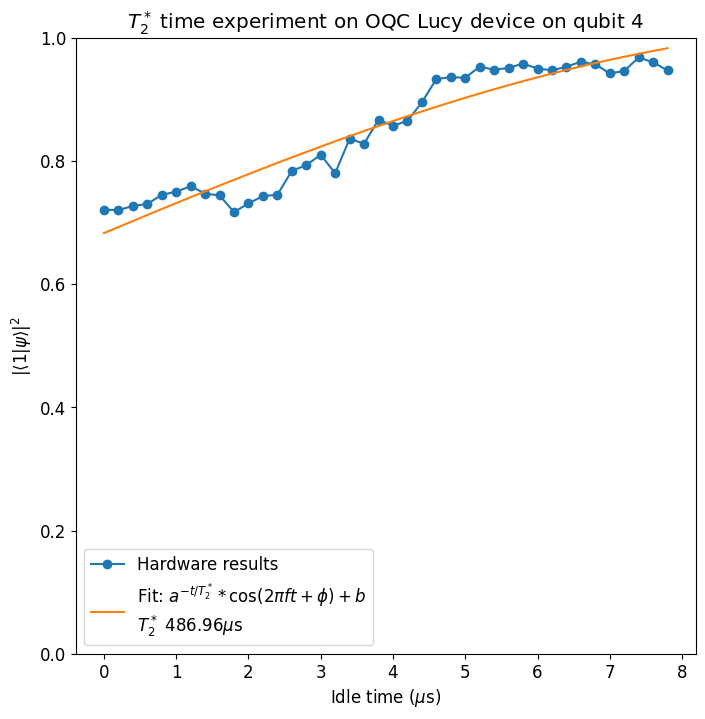

In [26]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))
wait_lengths = [wait_time_s * n * 1e6 for n in nums_identities]

ax.plot(wait_lengths, prob_1s, "-o", label="Hardware results")
ax.plot(wait_lengths, fitted_probs, label=f"Fit: " + r"$a^{-t/{T_2^*}}*\cos(2\pi f t+\phi)+b$" + 
        '\n' + r"$T_2^*$" + f" {1/fit_result.x[1] * wait_time_s * 1e6:.2f}" + r"$\mu$s")
ax.set_xlabel(f"Idle time " + r"($\mu$s)")
# ax.set_xticks(nums_identities)
ax.set_ylim(0, 1)
ax.set_ylabel(r"$|⟨1|\psi⟩|^2$")
ax.legend()
plt.title(r"$T_2^*$" + f" time experiment on OQC Lucy device on qubit {qubit}")
plt.savefig(submitter.benchmark_path + "/plot.png", format="png")
plt.show()